# Descripción del dataset

Este dataset es un recopilatorio ventas de cartas Pokémon en diversos establecimientos internacionales. Toma cartas tanto antiguas como recientes y los precios se encuentras estandarizados a dolar.

Este registro cuanta con 542 entradas y 32 columnas distribuidas en:

Variables numericas:
* card_number: numero unico de carta
* numeric_grade: grado certificado numerico
* price: precio moneda local
* price_usd: precio en dolares
* seller_listing_count: cantidad de cartas listadas

* image_count: cantidad de imagenes subidas por el vendedor
* days_since_sold: dias desde la ultima venta
* sale_month: mes de venta
* sale_year: año de venta

Variables categoricas:
* title: titulo completo de la carta
* pokemon_name: pokemon en carta
* set_name: nombre de coleccion a la que pertenece la carta
* rarity_class: rareza
* language: idioma
* category: categoria de venta
* condition_std: condicion
* ship_worldwide: envio internacional (1 si envia, 0 si no envia)
* is_graded: si se encuentra gradeada (1 si lo esta)
* grading_company: compañia que realizo el gradeo
* is_holo: si es holografica (1 si lo esta)
* is_full_art: si tiene arte completo (1 si lo esta)
* is_v_card: si la carta es tipo V (1 si lo esta)
* is_ex_card: si la carta es tipo ex (1 si lo esta)
* is_gx_card: si la carta es tipo gx (1 si lo esta)
* is_promo: si la carta es promocional (1 si lo esta)
* is_shadowless: si la carta es con sombra alternativa (1 si lo esta)
* is_1st_edition: si la carta es primera edicion (1 si lo esta)
* is_rainbow: si la carta tiene foil arcoiris (1 si lo esta)
* is_gold: si la carta es dorada (1 si lo esta)
* currency: tipo moneda local
* price_tier_usd: rango de precio (Budget <$2, Common $2-10, Uncommon $10-50, Rare $50-200, Ultra Rare $200+ )
* seller_country: pais del vendedor

El objetivo del analisis es comprender la estructura del mercado de cartas Pokémon, identificar patrones de precio, calidad de las cartas y posibles factores asociados al valor de una carta.

Fuente: https://www.kaggle.com/datasets/kanchana1990/e-commerce-pokmon-card-pricing-data

## Sección 0 — Configuración inicial

In [7]:
# ============================================================
#   PARÁMETROS
# ============================================================
FILEPATH     = 'dataset4_pokemon_cards_ultimate_2026.csv'
TARGET       = 'price_usd'
TEST_SIZE    = 0.2
RANDOM_STATE = 42


In [8]:
# ============================================================
#   IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.pipeline         import make_pipeline
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, classification_report,
                                       ConfusionMatrixDisplay, roc_curve)
from scipy.stats              import randint, uniform

print('✅ Imports OK')

✅ Imports OK


In [10]:
# ============================================================
#   CARGA DE DATOS
# ============================================================
df = pd.read_csv(FILEPATH)
df = df.reset_index(drop=True)
df = df.drop(columns=['title', 'card_number', 'category'])

print(f'Shape: {df.shape}')
display(df.head())
print()
display(df.tail())

Shape: (542, 29)


,pokemon_name,set_name,rarity_class,language,condition_std,is_graded,grading_company,numeric_grade,is_holo,is_full_art,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge,SV8A,SAR,Japanese,Near Mint,0,NaN,NaN,0,0,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian,S12A,SAR,Japanese,Near Mint,0,NaN,NaN,1,0,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup,INFERNO X,AR,Japanese,Near Mint,0,NaN,NaN,0,0,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,Kyurem,XY,Unknown,English,Near Mint,0,NaN,NaN,1,0,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Vulpix,MEGA BRAVE,AR,Japanese,Near Mint,0,NaN,NaN,0,0,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


,pokemon_name,set_name,rarity_class,language,condition_std,is_graded,grading_company,numeric_grade,is_holo,is_full_art,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
537,Charizard,Unknown,SIR,English,Near Mint,0,NaN,NaN,0,0,...,GBP,394.35,Ultra Rare,United Kingdom,4,0,13,5.0,5.0,2026.0
538,Lucario,Unknown,Unknown,English,Near Mint,0,NaN,NaN,1,1,...,GBP,36.16,Uncommon,United Kingdom,5,0,10,5.0,5.0,2026.0
539,Blastoise,XY,Rare,English,Near Mint,0,NaN,NaN,1,1,...,EUR,11.73,Uncommon,Germany,1,1,6,5.0,5.0,2026.0
540,Venusaur,Unknown,Rare,English,Near Mint,0,NaN,NaN,0,1,...,GBP,152.12,Rare,United Kingdom,1,0,3,5.0,5.0,2026.0
541,Dragonite,XY6,Unknown,Japanese,Near Mint,0,NaN,NaN,1,0,...,GBP,6.80,Common,United Kingdom,1,0,5,5.0,5.0,2026.0


---
## Sección I — Exploración y Limpieza (EDA)

### I.1 — Información general

In [15]:
print('================================= Info =================================')
df.info()
print()
# tipos de datos deben ser modificado, aunque algunos valores como el año y mes de venta estan como float, podria optimizarse transformandolo a int y la mayoria de booleanos estan como numericos

# mes y año a int para mejor manejo
df['sale_month'] = df['sale_month'].astype('Int64')
df['sale_year'] = df['sale_year'].astype('Int64')

# conversion de categoria binaria a booleano
boolean_cols = [
    'is_graded', 'is_holo', 'is_full_art', 'is_v_card', 'is_ex_card',
    'is_gx_card', 'is_promo', 'is_shadowless', 'is_1st_edition',
    'is_rainbow', 'is_gold', 'ships_worldwide'
]

df[boolean_cols] = df[boolean_cols].astype(bool)

print('================================= Describe =================================')
display(df.describe().T)
print('================================= Variables Categóricas =================================')
cat_cols = df.select_dtypes(include='object').columns
cat_stats = pd.DataFrame({
    'n_unique'  : df[cat_cols].nunique(),
    'moda'      : df[cat_cols].mode().iloc[0],
    'frec_moda' : df[cat_cols].apply(lambda x: x.value_counts().iloc[0]),
    'pct_moda'  : df[cat_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100).round(1),
})
display(cat_stats)


# gradeado de cartas con muchos nulos, solo presente cartas con gradeo alto (9 y 10)
# columnas numericas en rangos posibles
# pokemon_name, set_name y rarity_class tienen como moda desconocido, a considerar si mantener estas columnas


================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pokemon_name          542 non-null    object 
 1   set_name              542 non-null    object 
 2   rarity_class          542 non-null    object 
 3   language              542 non-null    object 
 4   condition_std         542 non-null    object 
 5   is_graded             542 non-null    bool   
 6   grading_company       39 non-null     object 
 7   numeric_grade         30 non-null     float64
 8   is_holo               542 non-null    bool   
 9   is_full_art           542 non-null    bool   
 10  is_v_card             542 non-null    bool   
 11  is_ex_card            542 non-null    bool   
 12  is_gx_card            542 non-null    bool   
 13  is_promo              542 non-null    bool   
 14  i

,count,mean,std,min,25%,50%,75%,max
numeric_grade,30.0,9.6,0.498273,9.0,9.0,10.0,10.0,10.0
price,542.0,31.595166,124.768916,0.36,1.5,4.2,11.5025,1475.0
price_usd,542.0,39.830111,151.256,0.49,2.0325,5.34,15.16,1591.41
seller_listing_count,542.0,39.754613,42.45455,1.0,4.0,26.0,88.0,114.0
image_count,542.0,4.50369,3.864023,2.0,2.0,2.0,6.0,22.0
days_since_sold,538.0,3.730483,0.854302,2.0,3.0,4.0,4.0,5.0
sale_month,538.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0
sale_year,538.0,2026.0,0.0,2026.0,2026.0,2026.0,2026.0,2026.0


================================= Variables Categóricas =================================


,n_unique,moda,frec_moda,pct_moda
pokemon_name,76,Unknown,317,58.5
set_name,80,Unknown,338,62.4
rarity_class,13,Unknown,336,62.0
language,6,English,326,60.1
condition_std,10,Near Mint,397,73.2
grading_company,4,ACE,21,53.8
currency,3,GBP,369,68.1
price_tier_usd,5,Common,222,41.0
seller_country,5,United Kingdom,369,68.1


### I.2 — Duplicados

In [16]:
n_dup = df.duplicated().sum()
print(f'Filas iniciales : {len(df)}')
print(f'Duplicados      : {n_dup} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Filas tras limpieza: {len(df)}')
else:
    print('Sin duplicados ✓')

Filas iniciales : 542
Duplicados      : 35 (6.46%)
Filas tras limpieza: 507


### I.3 — Nulos

In [18]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': pct}).query('nulos > 0')
display(nulos_df if not nulos_df.empty else pd.DataFrame({'resultado': ['Sin nulos ✓']}))

# days_since_sold, sale_month y sale_year tendran sus filas nulas eliminadas por ser menores al 5%
# grading_company sera eliminada completamente, aya que para este analisis no nos interesa que compañia es mas respetada como gradeadora
# en caso de numeric_grade sera similar, dejaremos como identificador is_graded para que el modelo reconozca que una carta gradeada es mas cara, pero no que entre en detalle entre cual es mejor

df = df.drop(columns=['grading_company', 'numeric_grade'])

,nulos,porcentaje
grading_company,468,92.31
numeric_grade,477,94.08
days_since_sold,4,0.79
sale_month,4,0.79
sale_year,4,0.79


### I.4 — Inconsistencias categóricas

In [19]:
# no hay problemas con las columnas categoricas

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('================================= Value Counts =================================\n')
for col in cat_cols:
    print(f'===== {col} =====')
    display(df[col].value_counts())
    print()

print('================================= Verificación de capitalización =================================\n')
for col in cat_cols:
    original = df[col].nunique()
    lower    = df[col].str.lower().nunique()
    if original != lower:
        print(f"  ⚠️  INCONSISTENCIA en '{col}': {original} vs {lower}")
        df[col] = df[col].str.strip().str.lower()
    else:
        print(f"  '{col}': sin inconsistencias ✓")

================================= Value Counts =================================

===== pokemon_name =====


,count
pokemon_name,
Unknown,282
Pikachu,18
Charizard,14
Dragonite,9
Meowth,7
...,...
Calyrex,1
Yveltal,1
Dragapult,1



===== set_name =====


,count
set_name,
Unknown,305
BASE SET,30
TEAM ROCKET,15
JUNGLE,14
FOSSIL,10
...,...
SV7A,1
SV1A,1
S9,1



===== rarity_class =====


...


===== price_tier_usd =====


,count
price_tier_usd,
Common,207
Uncommon,127
Budget,120
Rare,27
Ultra Rare,26



===== seller_country =====


,count
seller_country,
United Kingdom,341
Germany,138
Italy,17
United States,10
Other,1



================================= Verificación de capitalización =================================

  'pokemon_name': sin inconsistencias ✓
  'set_name': sin inconsistencias ✓
  'rarity_class': sin inconsistencias ✓
  'language': sin inconsistencias ✓
  'condition_std': sin inconsistencias ✓
  'currency': sin inconsistencias ✓
  'price_tier_usd': sin inconsistencias ✓
  'seller_country': sin inconsistencias ✓


### I.5 — Outliers (IQR)

In [20]:
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_report = []
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'columna': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                           'lim_inf': round(lower,2), 'lim_sup': round(upper,2),
                           'outliers': n_out, 'pct': round(n_out/len(df)*100,2)})
display(pd.DataFrame(outlier_report))


,columna,Q1,Q3,lim_inf,lim_sup,outliers,pct
0,price,1.76,12.53,-14.38,28.68,71,14.0
1,price_usd,2.35,16.51,-18.89,37.75,72,14.2
2,seller_listing_count,3.00,88.00,-124.50,215.50,0,0.0
3,image_count,2.00,6.00,-4.00,12.00,37,7.3
4,days_since_sold,3.00,4.00,1.50,5.50,0,0.0
5,sale_month,5.00,5.00,5.00,5.00,0,0.0
6,sale_year,2026.00,2026.00,2026.00,2026.00,0,0.0


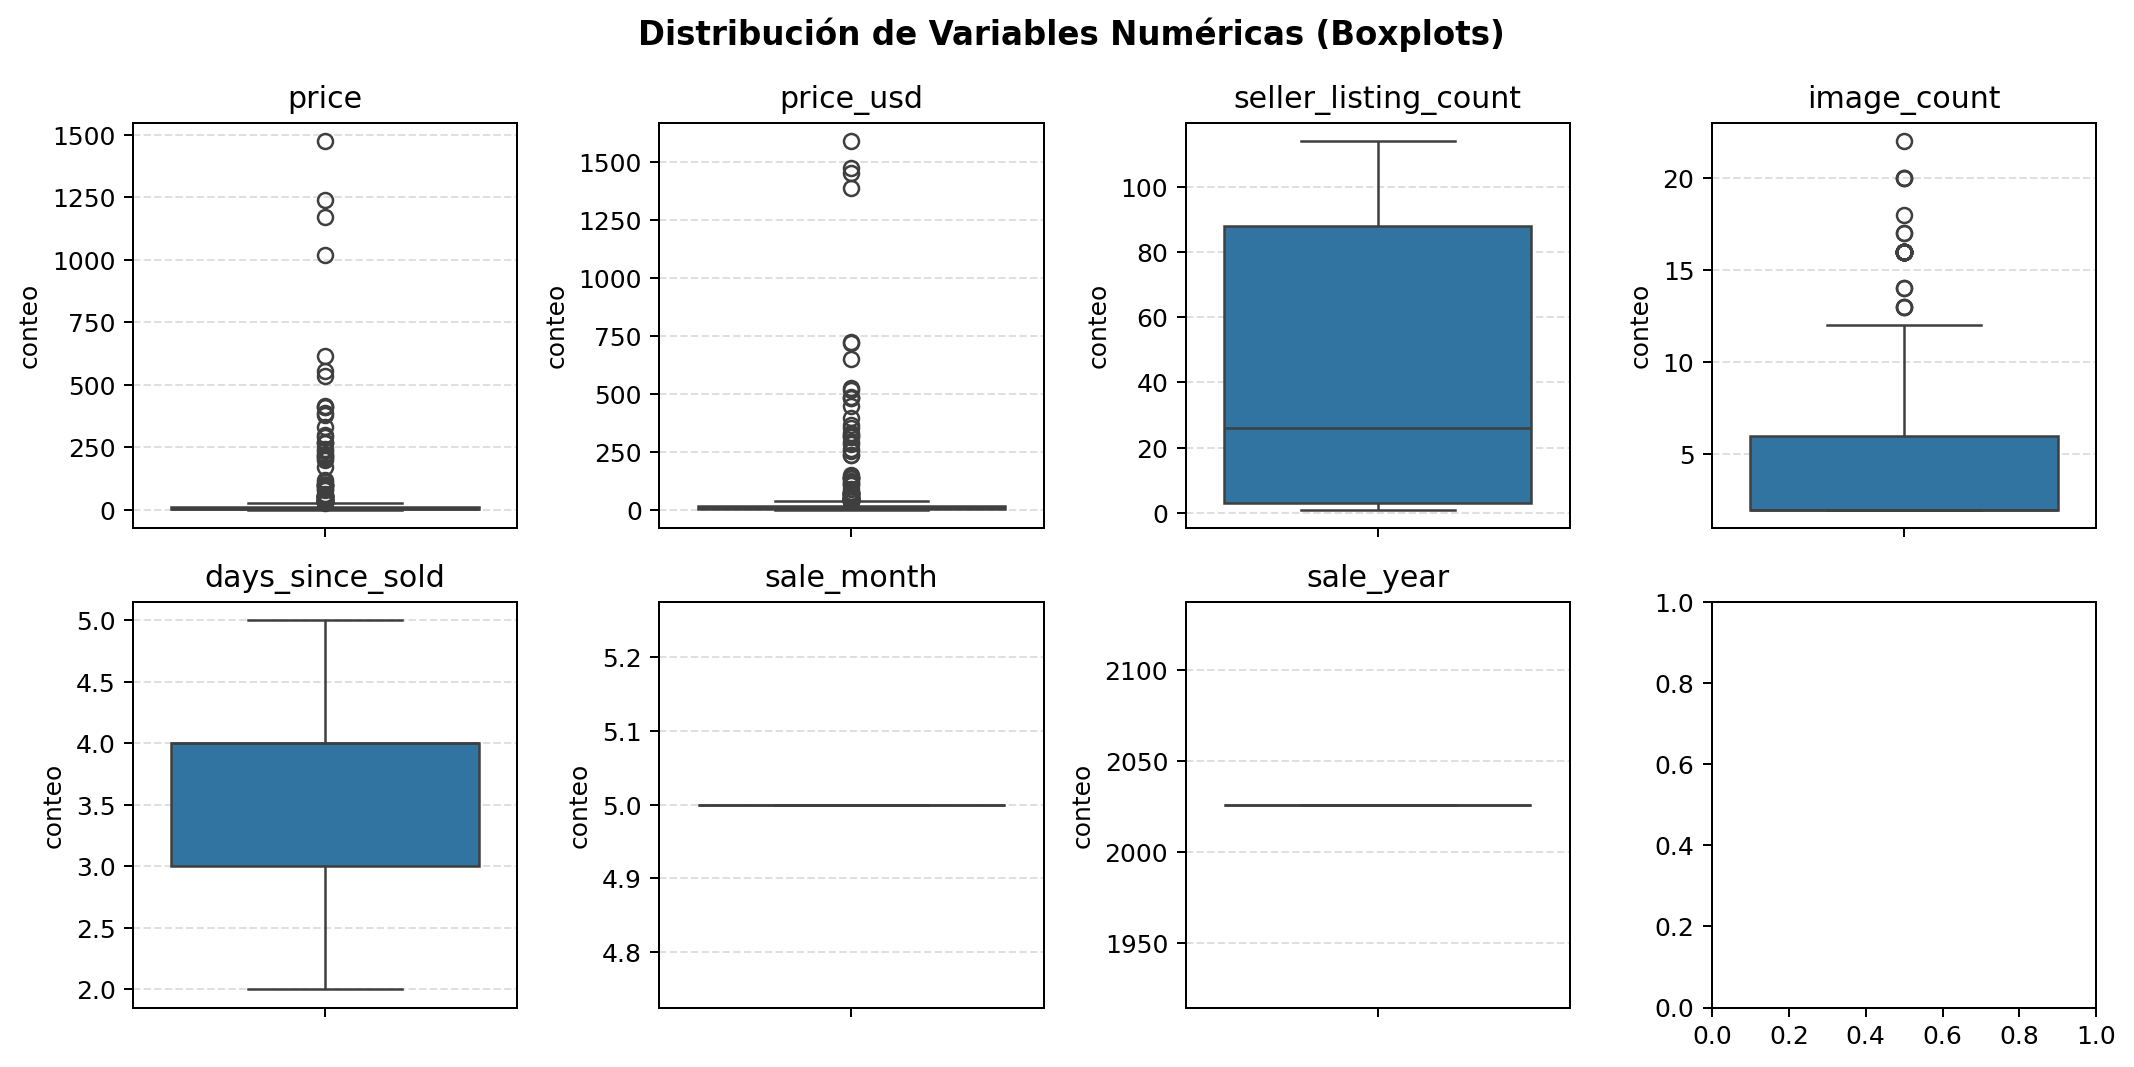

In [30]:
# boxplots
fig, axes = plt.subplots(2, 4, figsize=(12, 6), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('conteo')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Boxplots)', fontsize=13, fontweight='bold')
print()
plt.tight_layout(); plt.show()

Outliers dentro de rangos esperables, el numero de imagenes depende de cada vendedor y suele ser opcional, en cambio los precios en articulos de coleccion suelen ser elevados en articulos muy codiciados, "el cielo es el limite" resume perfectamente el techo de precio de estas cartas. Se mantienen los outliers.

### I.6 — Distribución

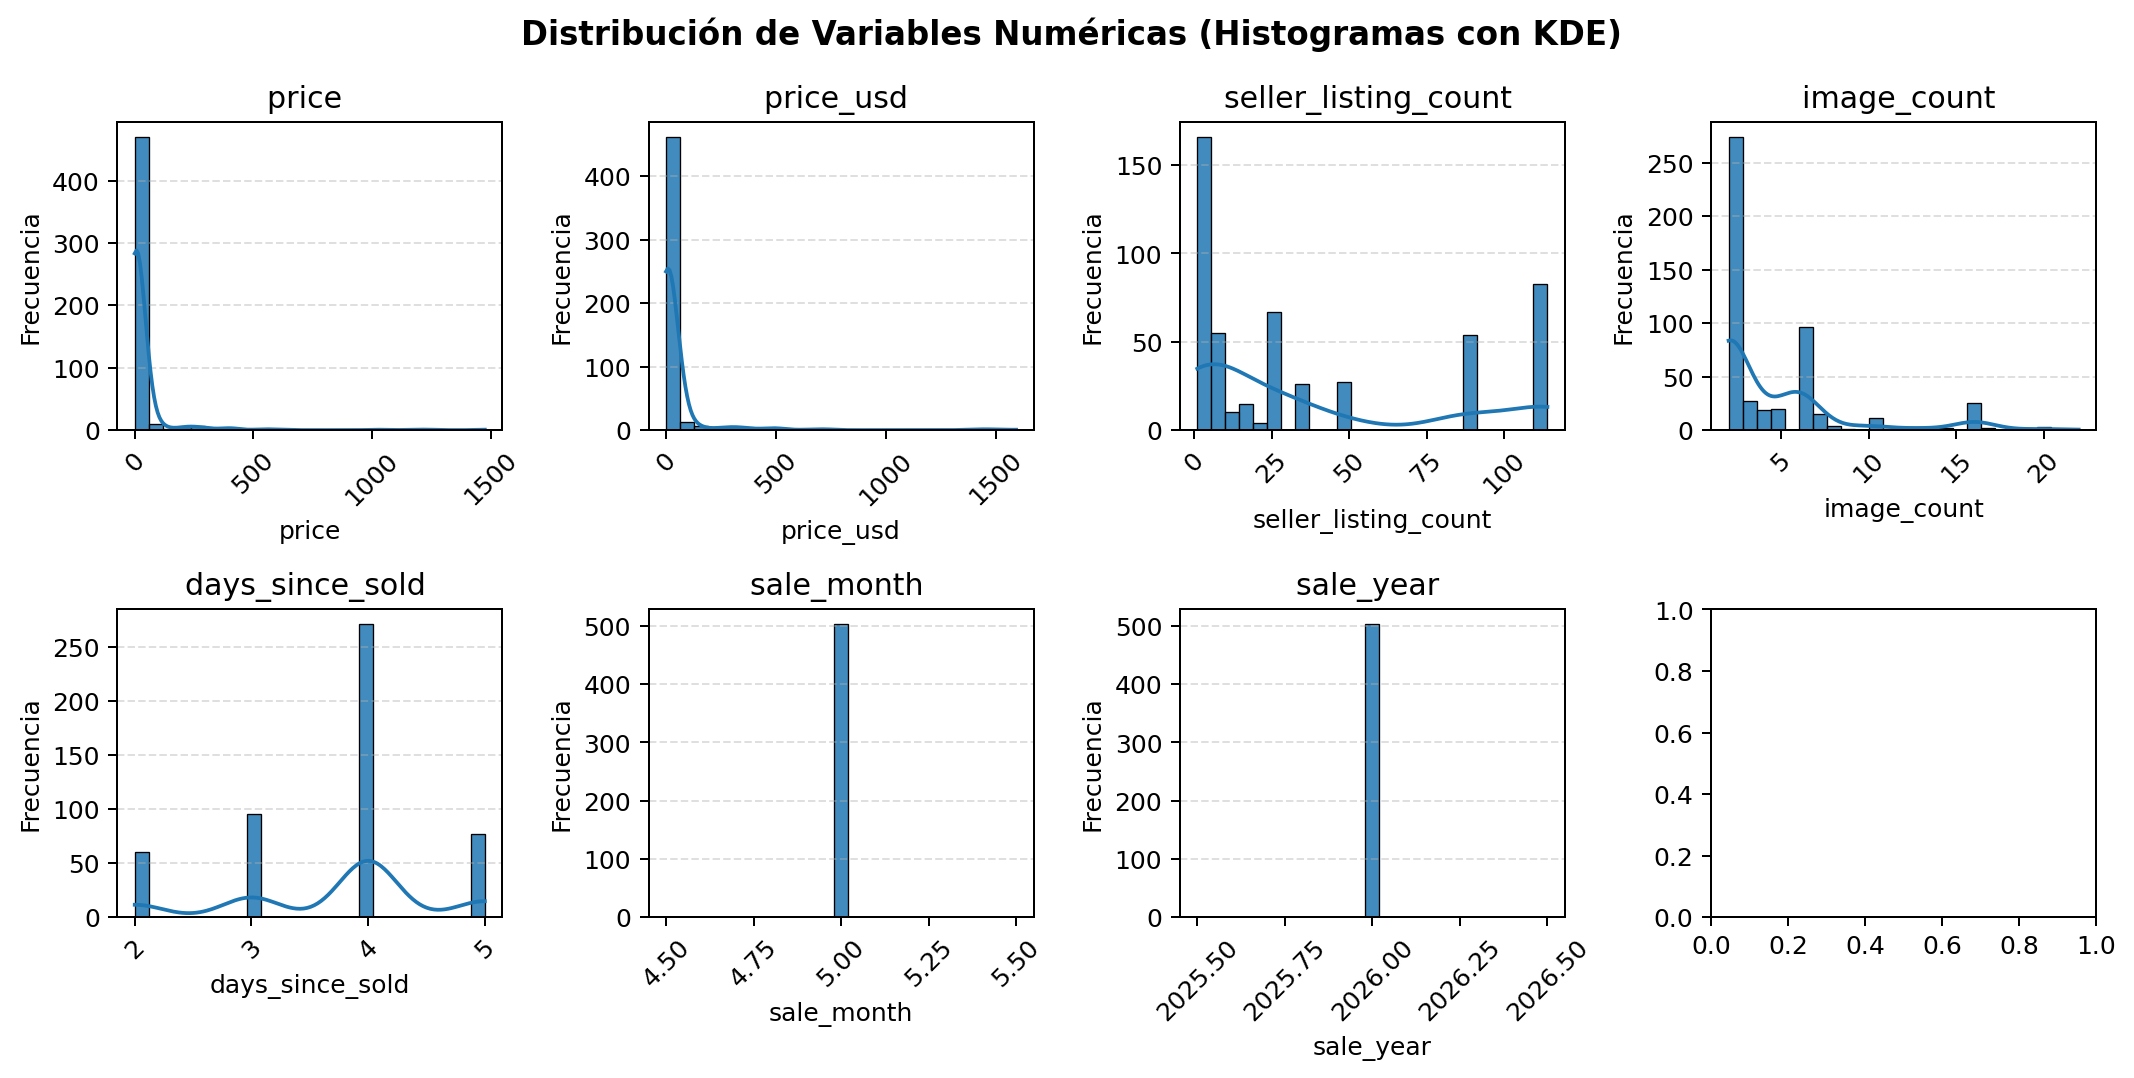

In [32]:
# Variables numericas
fig, axes = plt.subplots(2, 4, figsize=(12, 6), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=25, ax=ax, kde=True, alpha=0.85)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de Variables Numéricas (Histogramas con KDE)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


* En seller_listing_count puede apreciarse que existen vendedores mayoristas con una gran cantidad de cartas en venta y al mismo tiempo existen algunas personas minoristas con ventas de pocas unidades, posiblemente coleccionistas que venden por necesidad o cartas que no le interesaban desde un inicio y lograron obtener.
* el precio presenta una gran desigualdad, la mayoria de los precios se encuentran debajo de los 300 dolares, pero algunos casos extremos, probablemente articulos unicos desbalancean el grafico

### I.8 — Heatmap correlación

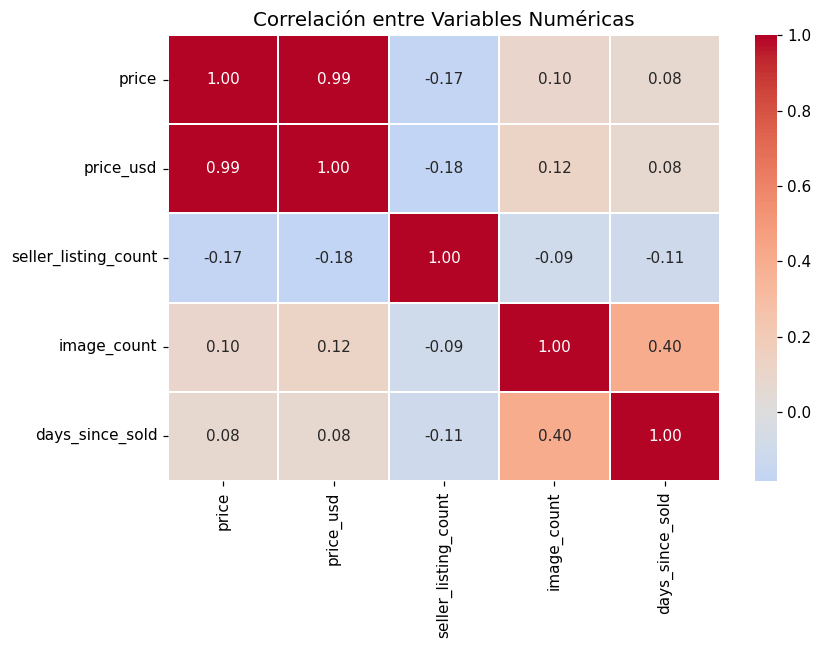


Correlaciones más fuertes con price_usd:
price                   0.993
seller_listing_count   -0.183
image_count             0.118
days_since_sold         0.079


In [49]:
num_for_corr = df.select_dtypes(include='number').columns.tolist()
num_for_corr.remove('sale_month')
num_for_corr.remove('sale_year')

plt.figure(figsize=(8, 6), dpi=110)
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3, annot_kws={'size':10})
plt.title('Correlación entre Variables Numéricas', fontsize=13)
plt.tight_layout(); plt.show()

print('\nCorrelaciones más fuertes con price_usd:')
corr_target = df[num_for_corr].corr()['price_usd'].drop('price_usd').sort_values(key=abs, ascending=False)
print(corr_target.head(10).round(3).to_string())

Como se esperaba, las variables numericas no tienen gran impacto en el precio, se espera que las variables categoricas sostengan en analisis predictivo

---
## Sección II — Resumen y hallazgos

In [50]:
print('=' * 65)
print('  INFORME FINAL —  POKEMON CARD PRICING')
print('=' * 65)

print(f'''
Dataset:
  Filas         : {len(df)}
  Columnas      : {df.shape[1]}
  Target        : price_usd
  Fuente        : Kaggle — E-commerce Pokémon Card Pricing Data


Outliers: Mantenidos, casos extremos pero plausibles
''')

print(f'''
Hallazgos principales:
 * Precios con distribucion asimetrica
 * Mercado certificado es pequeño
 * Gran cantidad de campos nulos
 * Dataset localizado mayormente en Reino unido


Desafíos:
 * Varias columnas necesitan un tratamiento previo
 * Gran cantidad de nulos
 * Falta de informacion adicional en caracteristicas de cartas
 * Precios extremos pueden ser un problema

''')
print('=' * 65)

  INFORME FINAL —  POKEMON CARD PRICING

Dataset:
  Filas         : 507
  Columnas      : 27
  Target        : price_usd 
  Fuente        : Kaggle — E-commerce Pokémon Card Pricing Data


Outliers: Mantenidos, casos extremos pero plausibles


Hallazgos principales:
 * Precios con distribucion asimetrica
 * Mercado certificado es pequeño
 * Gran cantidad de campos nulos
 * Dataset localizado mayormente en Reino unido


Desafíos:
 * Varias columnas necesitan un tratamiento previo
 * Gran cantidad de nulos
 * Falta de informacion adicional en caracteristicas de cartas
 * Precios extremos pueden ser un problema




Resumir los principales hallazgos de cada EDA, destacando las características y desafíos únicos de cada conjunto de datos